In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas version:", pd.__version__)
#print("matplotlib.pyplot version:", plt.__version__)
print("seaborn version:", sns.__version__)

pandas version: 2.3.2
seaborn version: 0.13.2


In [3]:
pd.options.display.max_columns = None
#pd.options.display.max_rows = None

This data is gathered from this website: https://www.rijdendetreinen.nl/en/open-data/train-archive

### Data Dictionary

Below you will find the data dictionary provided by Rijden-de-treinen.

Each row in these files represent a stop at a station. Each service at least departs from and arrives at a station (i.e. two rows). For each stop, you can find the name of the station, the arrival and departure time, delays and cancellations. The exact meaning of each column is explained below.

The source for this data is the real-time data from NS with live departure times, live arrival times and service updates. This data is also used in the app and website of Rijden Treinen.

#### Columns
- `Service:RDT-ID` *Unique identifier (service):* This is the ID that Rijden de Treinen uses for this service. It has no useful meaning beyond uniquely identifying a single service on a single date. This ID will occur more than once in the CSV files because this ID is unique for each service. There is also a column Stop:RDT-ID with a unique ID for each stop.
- `Service:Date` *Service date (schedule date):* The scheduled service date for this service. The service date is not always the same as the actual date. For example, a service that departs at 23:59 on 31 July and arrives at 02:00 on 1 August has a service date of 31 July. Delays do not affect the service date.
- `Service:Type` *Service type:* The service type, for example: *Intercity*, *Sprinter* or *ICE International*.
- `Service:Company` *Operator:* Company operating this service, like NS or Arriva.
- `Service:Train number` *Train number:* The train number (service number) for this service uniquely identifies this service on this date. This number is sometimes also communicated to passengers (especially for international trains). A single service may sometimes have multiple train numbers. For example, when a train is split in two parts, or when a train changes a train number on a major station halfway.
- `Service:Completely cancelled` *Service is fully cancelled:* This column is true when all stops of this service have been cancelled. Or in other words: when the train does not run at all.
- `Service:Partly cancelled` *Partially cancelled:* This column is true when one or more stops of this service have been cancelled. Or in other words: when the train does not run on a part of the route.
- `Service:Maximum delay` *Highest delay for this service:* The highest delay (**in minutes**) of all stops of this service.
- `Stop:RDT-ID` *Unique identifier (stop):* Unique identifier for this stop. This ID is unique for each stop in the dataset. It has no further useful meaning.
- `Stop:Station code` *Station code:* Code (abbreviation) of the station name. See also the [dataset with railway stations.](https://www.rijdendetreinen.nl/en/open-data/stations)
- `Stop:Station name` *Station name:* The name of the station.
- `Stop:Arrival time` *Arrival time:* Scheduled arrival time in **RFC 3339 format.** This column is empty when no arrival was scheduled.
- `Stop:Arrival delay` *Arrival delay:* Arrival delay **in minutes.** This column is empty when no arrival was scheduled.
- `Stop:Arrival cancelled` *Cancelled arrival:* This column is true when the arrival at this stop has been cancelled. This column is empty when no arrival was scheduled.
- `Stop:Departure time` *Departure time:* Scheduled departure time in **RFC 3339 format.** This column is empty when no departure was scheduled.
- `Stop:Departure delay` *Departure delay:* Departure delay **in minutes.** This column is empty when no departure was scheduled.
- `Stop:Departure cancelled` *Cancelled departure:* This column is true when the departure at this stop has been cancelled. This column is empty when no departure was scheduled.
- `Stop:Platform change` *Platform change:* This column is true when the platform of this stop has changed from the planned platform.
- `Stop:Planned platform` *Scheduled platform:* The originally scheduled platform for this service.
- `Stop:Actual platform` *Actual platform:* The platform that was actually used for this service.

In [6]:
df = pd.read_parquet('Data/no_missing_values_version1_traject_Eindhoven_sittard_2019_2025.parquet')
df.head()

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,departure_time,arrival_time,is_first_stop,is_last_stop,arrival_missing,departure_missing,departure_delay_missing,arrival_delay,prev_station,station_pair,arrival_delay_missing,hour,day_of_week,month,is_weekend,is_rushhour,departure_delay,is_delayed
0,738846,2019-01-01,Intercity,NS,2925,False,False,5,6220367,EKZ,Enkhuizen,NaT,NaN,None,2019-01-01 05:39:00+00:00,0.0,False,False,1,1,2019-01-01 05:39:00+00:00,NaT,True,False,True,False,False,NaN,None,None,True,5.0,1.0,1.0,0,0,0.0,False
1,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220388,BKF,Bovenkarspel Flora,2019-01-01 05:43:00+00:00,0.0,False,2019-01-01 05:43:00+00:00,0.0,False,False,1,1,2019-01-01 05:43:00+00:00,2019-01-01 05:43:00+00:00,False,False,False,False,False,0.0,EKZ,EKZ_BKF,False,5.0,1.0,1.0,0,0,0.0,False
2,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220405,BKG,Bovenkarspel-Grootebroek,2019-01-01 05:45:00+00:00,0.0,False,2019-01-01 05:47:00+00:00,0.0,False,False,2,2,2019-01-01 05:47:00+00:00,2019-01-01 05:45:00+00:00,False,False,False,False,False,0.0,BKF,BKF_BKG,False,5.0,1.0,1.0,0,0,0.0,False
3,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220435,HKS,Hoogkarspel,2019-01-01 05:52:00+00:00,0.0,False,2019-01-01 05:52:00+00:00,0.0,False,False,2,2,2019-01-01 05:52:00+00:00,2019-01-01 05:52:00+00:00,False,False,False,False,False,0.0,BKG,BKG_HKS,False,5.0,1.0,1.0,0,0,0.0,False
4,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220479,HNK,Hoorn Kersenboogerd,2019-01-01 05:58:00+00:00,1.0,False,2019-01-01 05:59:00+00:00,0.0,False,False,1,1,2019-01-01 05:59:00+00:00,2019-01-01 05:58:00+00:00,False,False,False,False,False,1.0,HKS,HKS_HNK,False,5.0,1.0,1.0,0,0,0.0,False


In [7]:
df["is_delayed"] = df["is_delayed"].astype(int)
df

,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station code,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,Stop:Planned platform,Stop:Actual platform,departure_time,arrival_time,is_first_stop,is_last_stop,arrival_missing,departure_missing,departure_delay_missing,arrival_delay,prev_station,station_pair,arrival_delay_missing,hour,day_of_week,month,is_weekend,is_rushhour,departure_delay,is_delayed
0,738846,2019-01-01,Intercity,NS,2925,False,False,5,6220367,EKZ,Enkhuizen,NaT,NaN,None,2019-01-01 05:39:00+00:00,0.0,False,False,1,1,2019-01-01 05:39:00+00:00,NaT,True,False,True,False,False,NaN,None,None,True,5.0,1.0,1.0,0,0,0.0,0
1,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220388,BKF,Bovenkarspel Flora,2019-01-01 05:43:00+00:00,0.0,False,2019-01-01 05:43:00+00:00,0.0,False,False,1,1,2019-01-01 05:43:00+00:00,2019-01-01 05:43:00+00:00,False,False,False,False,False,0.0,EKZ,EKZ_BKF,False,5.0,1.0,1.0,0,0,0.0,0
2,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220405,BKG,Bovenkarspel-Grootebroek,2019-01-01 05:45:00+00:00,0.0,False,2019-01-01 05:47:00+00:00,0.0,False,False,2,2,2019-01-01 05:47:00+00:00,2019-01-01 05:45:00+00:00,False,False,False,False,False,0.0,BKF,BKF_BKG,False,5.0,1.0,1.0,0,0,0.0,0
3,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220435,HKS,Hoogkarspel,2019-01-01 05:52:00+00:00,0.0,False,2019-01-01 05:52:00+00:00,0.0,False,False,2,2,2019-01-01 05:52:00+00:00,2019-01-01 05:52:00+00:00,False,False,False,False,False,0.0,BKG,BKG_HKS,False,5.0,1.0,1.0,0,0,0.0,0
4,738846,2019-01-01,Intercity,NS,2925,False,False,0,6220479,HNK,Hoorn Kersenboogerd,2019-01-01 05:58:00+00:00,1.0,False,2019-01-01 05:59:00+00:00,0.0,False,False,1,1,2019-01-01 05:59:00+00:00,2019-01-01 05:58:00+00:00,False,False,False,False,False,1.0,HKS,HKS_HNK,False,5.0,1.0,1.0,0,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838791,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097396,EHV,Eindhoven Centraal,2025-08-31 14:57:00+00:00,0.0,True,2025-08-31 14:59:00+00:00,0.0,True,False,None,None,2025-08-31 14:59:00+00:00,2025-08-31 14:57:00+00:00,False,False,False,False,False,0.0,HT,HT_EHV,False,14.0,6.0,8.0,1,0,0.0,0
2838792,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097397,WT,Weert,2025-08-31 15:16:00+00:00,0.0,True,2025-08-31 15:16:00+00:00,0.0,True,False,None,None,2025-08-31 15:16:00+00:00,2025-08-31 15:16:00+00:00,False,False,False,False,False,0.0,EHV,EHV_WT,False,15.0,6.0,8.0,1,0,0.0,0
2838793,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097398,RM,Roermond,2025-08-31 15:29:00+00:00,0.0,True,2025-08-31 15:30:00+00:00,0.0,True,False,None,None,2025-08-31 15:30:00+00:00,2025-08-31 15:29:00+00:00,False,False,False,False,False,0.0,WT,WT_RM,False,15.0,6.0,8.0,1,0,0.0,0
2838794,16713265,2025-08-31,Intercity,NS,302957,True,True,0,151097399,STD,Sittard,2025-08-31 15:45:00+00:00,0.0,True,2025-08-31 15:46:00+00:00,0.0,True,False,None,None,2025-08-31 15:46:00+00:00,2025-08-31 15:45:00+00:00,False,False,False,False,False,0.0,RM,RM_STD,False,15.0,6.0,8.0,1,0,0.0,0


In [8]:
df["ref_time"] = df["departure_time"].fillna(df["arrival_time"])

# df = df.dropna(subset=["ref_time"])

df["ref_hour"] = df["ref_time"].dt.hour
df["ref_day_of_week"] = df["ref_time"].dt.dayofweek
df["ref_month"] = df["ref_time"].dt.month

df["ref_is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df["ref_is_rushhour"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

In [9]:
import numpy as np

df["ref_hour_sin"] = np.sin(2 * np.pi * df["ref_hour"] / 24)
df["ref_hour_cos"] = np.cos(2 * np.pi * df["ref_hour"] / 24)

df["ref_dow_sin"] = np.sin(2 * np.pi * df["ref_day_of_week"] / 7)
df["ref_dow_cos"] = np.cos(2 * np.pi * df["ref_day_of_week"] / 7)

df[["ref_hour", "ref_hour_sin", "ref_hour_cos", "ref_day_of_week", "ref_dow_sin", "ref_dow_cos"]].head()

# mean normilasation

,ref_hour,ref_hour_sin,ref_hour_cos,ref_day_of_week,ref_dow_sin,ref_dow_cos
0,5,0.965926,0.258819,1,0.781831,0.62349
1,5,0.965926,0.258819,1,0.781831,0.62349
2,5,0.965926,0.258819,1,0.781831,0.62349
3,5,0.965926,0.258819,1,0.781831,0.62349
4,5,0.965926,0.258819,1,0.781831,0.62349


In [10]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "ref_hour_sin",
    "ref_hour_cos",
    "ref_dow_sin",
    "ref_dow_cos",
    "ref_is_weekend",
    "ref_is_rushhour",
    "ref_month",
    "is_first_stop",
    "is_last_stop"
]

X = df[feature_cols]
y = df["is_delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(is_delayed
 0    0.958044
 1    0.041956
 Name: proportion, dtype: float64,
 is_delayed
 0    0.958044
 1    0.041956
 Name: proportion, dtype: float64)

In [11]:
df[feature_cols].isna().sum()

ref_hour_sin       0
ref_hour_cos       0
ref_dow_sin        0
ref_dow_cos        0
ref_is_weekend     0
ref_is_rushhour    0
ref_month          0
is_first_stop      0
is_last_stop       0
dtype: int64

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

logreg_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced"
    ))
])

logreg_clf.fit(X_train, y_train)

y_pred_lr = logreg_clf.predict(X_test)
y_proba_lr = logreg_clf.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.970     0.573     0.720    543939
           1      0.057     0.589     0.104     23821

    accuracy                          0.574    567760
   macro avg      0.513     0.581     0.412    567760
weighted avg      0.931     0.574     0.695    567760

ROC-AUC: 0.6205773238438208


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    class_weight="balanced"
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.972     0.608     0.748    543939
           1      0.063     0.598     0.113     23821

    accuracy                          0.607    567760
   macro avg      0.517     0.603     0.431    567760
weighted avg      0.934     0.607     0.721    567760

ROC-AUC: 0.6512901668701064


### Time series

In [15]:
df_timeseries = pd.read_parquet('Data/no_missing_values_version1_TimeSeries_traject_Eindhoven_sittard_2019_2025.parquet')
df_timeseries

,date,arrival_delay,is_delayed,arrival_time,hour,day_of_week,month,is_weekend,is_rushhour,prev_station,direction,prev_station_mean_7,prev_station_mean_30,prev_station_std_30,lag1,lag7,lag30,rolling_mean_7_ehv,rolling_mean_30_ehv,rolling_std_30_ehv,hour_sin,hour_cos,dow_sin,dow_cos
0,2019-01-01,0.0,False,2019-01-01 07:32:00+00:00,7.0,1.0,1.0,0,1,WT,to_north,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.965926,-0.258819,0.781831,0.62349
1,2019-01-01,4.0,False,2019-01-01 07:59:00+00:00,8.0,1.0,1.0,0,1,HT,to_south,NaN,NaN,NaN,NaN,NaN,NaN,0.857143,0.566667,1.250747,0.866025,-0.500000,0.781831,0.62349
2,2019-01-01,0.0,False,2019-01-01 08:02:00+00:00,8.0,1.0,1.0,0,1,WT,to_north,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.866025,-0.500000,0.781831,0.62349
3,2019-01-01,0.0,False,2019-01-01 08:32:00+00:00,8.0,1.0,1.0,0,1,WT,to_north,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.866025,-0.500000,0.781831,0.62349
4,2019-01-01,0.0,False,2019-01-01 08:51:00+00:00,8.0,1.0,1.0,0,1,WT,to_north,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.866025,-0.500000,0.781831,0.62349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189228,2025-08-31,1.0,False,2025-08-31 20:26:00+00:00,20.0,6.0,8.0,1,0,HT,to_south,4.949271,3.331846,2.482292,4.0,10.0,32.0,6.285714,6.366667,6.228319,-0.866025,0.500000,-0.781831,0.62349
189229,2025-08-31,0.0,False,2025-08-31 20:31:00+00:00,20.0,6.0,8.0,1,0,WT,to_north,0.753267,0.723819,0.273204,0.0,0.0,0.0,0.857143,0.566667,1.250747,-0.866025,0.500000,-0.781831,0.62349
189230,2025-08-31,4.0,False,2025-08-31 20:57:00+00:00,20.0,6.0,8.0,1,0,HT,to_south,4.949271,3.331846,2.482292,1.0,5.0,4.0,5.000000,5.333333,4.002873,-0.866025,0.500000,-0.781831,0.62349
189231,2025-08-31,9.0,True,2025-08-31 21:26:00+00:00,21.0,6.0,8.0,1,0,HT,to_south,4.949271,3.331846,2.482292,4.0,4.0,9.0,4.857143,5.333333,4.002873,-0.707107,0.707107,-0.781831,0.62349


In [16]:
majority_class = df_timeseries["is_delayed"].mode()[0]
print("Majority Class: ", majority_class)

Majority Class:  False


In [17]:
df_timeseries["naive_majority_pred"] = majority_class

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = df_timeseries["is_delayed"]
y_pred = df_timeseries["naive_majority_pred"]

majority_accuracy  = accuracy_score(y_true, y_pred)
majority_precision = precision_score(y_true, y_pred, zero_division=0)
majority_recall    = recall_score(y_true, y_pred, zero_division=0)
majority_f1        = f1_score(y_true, y_pred, zero_division=0)

print("Majority Baseline:")
print("Accuracy :", majority_accuracy)
print("Precision:", majority_precision)
print("Recall   :", majority_recall)
print("F1-score :", majority_f1)

Majority Baseline:
Accuracy : 0.933822324858772
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


In [19]:
df_timeseries = df_timeseries.sort_values("arrival_time")

df_timeseries["lag1_label"] = df_timeseries.groupby("prev_station")["is_delayed"].shift(1)

# Use majority class as fallback voor de eerste paar rijen
df_timeseries["lag1_label"].fillna(majority_class, inplace=True)

y_true = df_timeseries["is_delayed"]
y_pred = df_timeseries["lag1_label"]

majority_accuracy  = accuracy_score(y_true, y_pred)
majority_precision = precision_score(y_true, y_pred, zero_division=0)
majority_recall    = recall_score(y_true, y_pred, zero_division=0)
majority_f1        = f1_score(y_true, y_pred, zero_division=0)

print("Lag1 Baseline:")
print("Accuracy :", majority_accuracy)
print("Precision:", majority_precision)
print("Recall   :", majority_recall)
print("F1-score :", majority_f1)

Lag1 Baseline:
Accuracy : 0.8943154735167756
Precision: 0.2014853857211308
Recall   : 0.20146929649445022
F1-score : 0.20147734078658414


C:\Users\kbruy\AppData\Local\Temp\ipykernel_17856\899406505.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_timeseries["lag1_label"].fillna(majority_class, inplace=True)
C:\Users\kbruy\AppData\Local\Temp\ipykernel_17856\899406505.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_timeseries["lag1_lab

In [20]:
df_timeseries = pd.get_dummies(df_timeseries, columns=["direction"])
df_timeseries

,date,arrival_delay,is_delayed,arrival_time,hour,day_of_week,month,is_weekend,is_rushhour,prev_station,prev_station_mean_7,prev_station_mean_30,prev_station_std_30,lag1,lag7,lag30,rolling_mean_7_ehv,rolling_mean_30_ehv,rolling_std_30_ehv,hour_sin,hour_cos,dow_sin,dow_cos,naive_majority_pred,lag1_label,direction_to_north,direction_to_south
0,2019-01-01,0.0,False,2019-01-01 07:32:00+00:00,7.0,1.0,1.0,0,1,WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.965926,-0.258819,0.781831,0.62349,False,False,True,False
1,2019-01-01,4.0,False,2019-01-01 07:59:00+00:00,8.0,1.0,1.0,0,1,HT,NaN,NaN,NaN,NaN,NaN,NaN,0.857143,0.566667,1.250747,0.866025,-0.500000,0.781831,0.62349,False,False,False,True
2,2019-01-01,0.0,False,2019-01-01 08:02:00+00:00,8.0,1.0,1.0,0,1,WT,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.866025,-0.500000,0.781831,0.62349,False,False,True,False
3,2019-01-01,0.0,False,2019-01-01 08:32:00+00:00,8.0,1.0,1.0,0,1,WT,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.866025,-0.500000,0.781831,0.62349,False,False,True,False
4,2019-01-01,0.0,False,2019-01-01 08:51:00+00:00,8.0,1.0,1.0,0,1,WT,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.866025,-0.500000,0.781831,0.62349,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189228,2025-08-31,1.0,False,2025-08-31 20:26:00+00:00,20.0,6.0,8.0,1,0,HT,4.949271,3.331846,2.482292,4.0,10.0,32.0,6.285714,6.366667,6.228319,-0.866025,0.500000,-0.781831,0.62349,False,False,False,True
189229,2025-08-31,0.0,False,2025-08-31 20:31:00+00:00,20.0,6.0,8.0,1,0,WT,0.753267,0.723819,0.273204,0.0,0.0,0.0,0.857143,0.566667,1.250747,-0.866025,0.500000,-0.781831,0.62349,False,False,True,False
189230,2025-08-31,4.0,False,2025-08-31 20:57:00+00:00,20.0,6.0,8.0,1,0,HT,4.949271,3.331846,2.482292,1.0,5.0,4.0,5.000000,5.333333,4.002873,-0.866025,0.500000,-0.781831,0.62349,False,False,False,True
189231,2025-08-31,9.0,True,2025-08-31 21:26:00+00:00,21.0,6.0,8.0,1,0,HT,4.949271,3.331846,2.482292,4.0,4.0,9.0,4.857143,5.333333,4.002873,-0.707107,0.707107,-0.781831,0.62349,False,False,False,True


In [21]:
from sklearn.model_selection import train_test_split

feature_cols = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "is_rushhour",
    "month",
    "direction_to_north",
    "direction_to_south",
    "prev_station_mean_7",
    "prev_station_mean_30",
    "prev_station_std_30",
    "lag1",
    "lag7",
    "lag30",
    "rolling_mean_7_ehv",
    "rolling_mean_30_ehv",
    "rolling_std_30_ehv"
]

X = df_timeseries[feature_cols]
y = df_timeseries["is_delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(is_delayed
 False    0.933825
 True     0.066175
 Name: proportion, dtype: float64,
 is_delayed
 False    0.933812
 True     0.066188
 Name: proportion, dtype: float64)

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_clf = RandomForestClassifier(
    class_weight="balanced"
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
              precision    recall  f1-score   support

       False      0.934     0.993     0.963     35342
        True      0.153     0.018     0.032      2505

    accuracy                          0.928     37847
   macro avg      0.544     0.505     0.497     37847
weighted avg      0.883     0.928     0.901     37847

ROC-AUC: 0.7126311465123626


C:\Users\kbruy\AppData\Local\Temp\ipykernel_17856\3971799587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette="viridis")


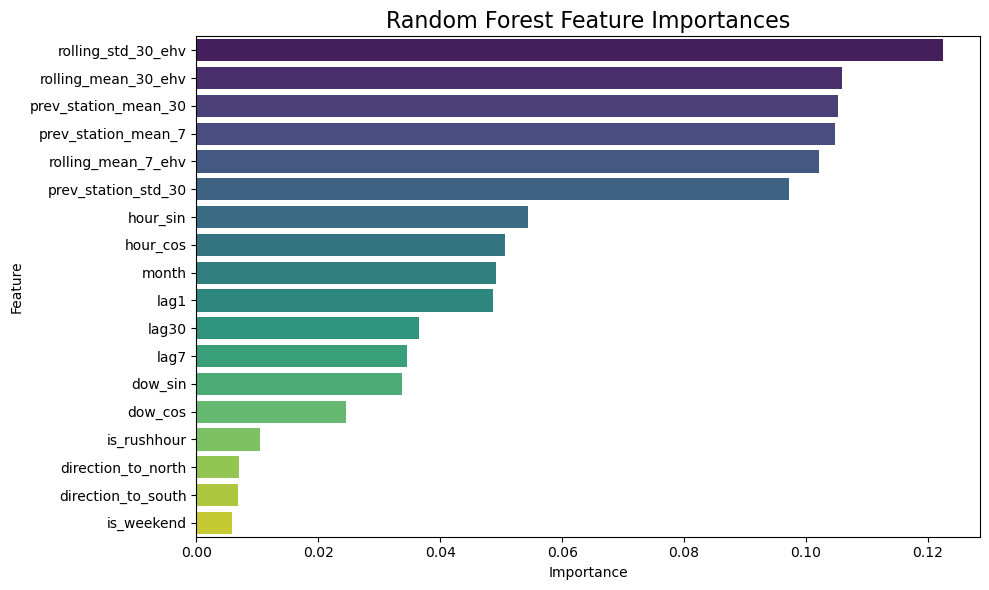

In [23]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x=importances, y=importances.index, palette="viridis")
plt.title("Random Forest Feature Importances", fontsize=16)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()